In [1]:
import numpy as np
import pandas as pd
import csv
import random
from sklearn.linear_model import LogisticRegression
import sys
import os

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
random.seed(0)
np.random.seed(0)

from utils import *

enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
YEAR = 2023

In [5]:
#class ratio must be [0,1]
#lower number means more aggressive spliting towards the higher classes

NUMBER_OF_CLASSES = 10
CLASS_RATIO = 0.55

In [6]:
base_path = f'../../data/{NUTS2}/results/'

In [7]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_CMacedonia_Results_2010-2022.csv',
 'GR_CMacedonia_Results_2023-August-1st.csv',
 'GR_CMacedonia_Results_2023-August-1st_(new).csv',
 'GR_CMacedonia_Results_2023-August-2nd_(new).csv',
 'GR_CMacedonia_Results_2023-July-1st.csv',
 'GR_CMacedonia_Results_2023-July-1st_(new).csv',
 'GR_CMacedonia_Results_2023-July-2nd.csv',
 'GR_CMacedonia_Results_2023-July-2nd_(new).csv',
 'GR_CMacedonia_Results_2023-June-1st.csv',
 'GR_CMacedonia_Results_2023-June-1st_(new).csv',
 'GR_CMacedonia_Results_2023-June-2nd.csv',
 'GR_CMacedonia_Results_2023-June-2nd_(new).csv',
 'GR_CMacedonia_Results_2023-May-1st.csv',
 'GR_CMacedonia_Results_2023-May-1st_(new).csv',
 'GR_CMacedonia_Results_2023-May-2nd.csv',
 'GR_CMacedonia_Results_2023-May-2nd_(new).csv']

In [8]:
file = file_list[0]

data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
data.drop(columns=['x', 'y'], inplace=True)
data.rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)


In [9]:
data

,lau1,day,month,year,case,score
0,πελλας,16,8,2018,1,9.916577e-01
1,αλεξανδρειας,16,8,2021,1,9.915538e-01
2,πελλας,16,8,2013,1,9.889352e-01
3,δελτα,16,8,2021,0,9.888012e-01
4,αλεξανδρειας,1,8,2021,1,9.882414e-01
...,...,...,...,...,...,...
6911,αριστοτελη,1,5,2011,0,7.750298e-07
6912,ναουσας,1,5,2019,0,7.256357e-07
6913,διου ολυμπου,1,5,2019,0,7.219914e-07
6914,ναουσας,1,5,2010,0,4.914442e-07


In [10]:
data_og = data.copy()

In [11]:
np.sort(data.month.unique())

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [12]:
np.sort(data.year.unique())

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [13]:
zero_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 0}
one_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 1}

In [14]:
data = data.append(zero_score, ignore_index = True)
data = data.append(one_score, ignore_index = True)

In [15]:
data

,lau1,day,month,year,case,score
0,πελλας,16,8,2018,1,9.916577e-01
1,αλεξανδρειας,16,8,2021,1,9.915538e-01
2,πελλας,16,8,2013,1,9.889352e-01
3,δελτα,16,8,2021,0,9.888012e-01
4,αλεξανδρειας,1,8,2021,1,9.882414e-01
...,...,...,...,...,...,...
6913,διου ολυμπου,1,5,2019,0,7.219914e-07
6914,ναουσας,1,5,2010,0,4.914442e-07
6915,διου ολυμπου,16,5,2022,0,3.798096e-07
6916,αγνωστη,0,0,0,0,0.000000e+00


In [16]:
data_sorted = data.sort_values(by='score', ascending=True)

In [17]:
data_sorted.reset_index(drop = True, inplace = True)

In [18]:
data_sorted

,lau1,day,month,year,case,score
0,αγνωστη,0,0,0,0,0.000000e+00
1,διου ολυμπου,16,5,2022,0,3.798096e-07
2,ναουσας,1,5,2010,0,4.914442e-07
3,διου ολυμπου,1,5,2019,0,7.219914e-07
4,ναουσας,1,5,2019,0,7.256357e-07
...,...,...,...,...,...,...
6913,δελτα,16,8,2021,0,9.888012e-01
6914,πελλας,16,8,2013,1,9.889352e-01
6915,αλεξανδρειας,16,8,2021,1,9.915538e-01
6916,πελλας,16,8,2018,1,9.916577e-01


<AxesSubplot:>

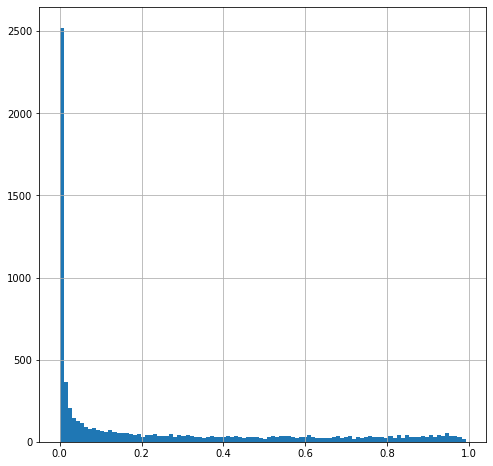

In [19]:
data_og.score.hist(bins = 100, figsize = (8,8))

In [20]:
number_of_observations = len(data_sorted)

In [21]:
r_sum = 0

for i in range(NUMBER_OF_CLASSES):
    r_sum = r_sum + CLASS_RATIO**i

x = round(number_of_observations/r_sum)

x

3121

In [22]:
temp_x = x
total_obs = 0
obs = []

for c in range(NUMBER_OF_CLASSES):
    total_obs = total_obs + temp_x
    obs.append(temp_x)
    print(f'Class {c}: {temp_x} observations')
    temp_x = round(temp_x*CLASS_RATIO)
    
print(f'\nTotal Observations: {total_obs}')

Class 0: 3121 observations
Class 1: 1717 observations
Class 2: 944 observations
Class 3: 519 observations
Class 4: 285 observations
Class 5: 157 observations
Class 6: 86 observations
Class 7: 47 observations
Class 8: 26 observations
Class 9: 14 observations

Total Observations: 6916


In [23]:
bins = []
sum = 0
for index in obs:
    sum = sum + index
    try:
        bin_lim = data_sorted.loc[sum, 'score']
    except KeyError:
        bin_lim = data_sorted.loc[number_of_observations-1, 'score']
    bins.append(bin_lim)

bins.insert(0,0)
bins[-1] = 1 

In [24]:
data_og['risk_class'] = pd.cut(data_og['score'], bins=bins, labels=False, include_lowest=True)

data_og.risk_class.value_counts().sort_index()

0    3121
1    1717
2     944
3     519
4     285
5     157
6      86
7      47
8      26
9      14
Name: risk_class, dtype: int64

In [25]:
bins_formatted = [ '%.4f' % elem for elem in bins]
print(bins_formatted)

['0.0000', '0.0315', '0.3207', '0.6347', '0.8115', '0.8978', '0.9411', '0.9611', '0.9747', '0.9837', '1.0000']


In [26]:
class9 = data_og.loc[data_og.risk_class == 9]
class8 = data_og.loc[data_og.risk_class == 8]
class7 = data_og.loc[data_og.risk_class == 7]
class6 = data_og.loc[data_og.risk_class == 6]
class5 = data_og.loc[data_og.risk_class == 5]
class4 = data_og.loc[data_og.risk_class == 4]
class3 = data_og.loc[data_og.risk_class == 3]
class2 = data_og.loc[data_og.risk_class == 2]
class1 = data_og.loc[data_og.risk_class == 1]
class0 = data_og.loc[data_og.risk_class == 0]

In [27]:
means = []

means.append(class0.case.mean())
means.append(class1.case.mean())
means.append(class2.case.mean())
means.append(class3.case.mean())
means.append(class4.case.mean())
means.append(class5.case.mean())
means.append(class6.case.mean())
means.append(class7.case.mean())
means.append(class8.case.mean())
means.append(class9.case.mean())

In [28]:
means

[0.0016020506247997437,
 0.07338380896913221,
 0.13559322033898305,
 0.11946050096339114,
 0.14736842105263157,
 0.1592356687898089,
 0.19767441860465115,
 0.2127659574468085,
 0.34615384615384615,
 0.7142857142857143]

In [49]:
class_bins = []

In [50]:
class_very_low = class0
class_very_low.reset_index(drop = True, inplace = True)
class_very_low

print(f'Threashold: ({class_very_low.score.min():.3f} - {class_very_low.score.max():.3f})')
print(f'Samples: {len(class_very_low)}')
print(f'% Samples: {len(class_very_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_low.case.mean() * 100 :.2f} %')

class_bins.append(0)

Threashold: (0.000 - 0.031)
Samples: 3121
% Samples: 45.127 %
Accuracy: 0.16 %


In [51]:
class_low = class1
class_low.reset_index(drop = True, inplace = True)
class_low

print(f'Threashold: ({class_low.score.min():.3f} - {class_low.score.max():.3f})')
print(f'Samples: {len(class_low)}')
print(f'% Samples: {len(class_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_low.case.mean() * 100 :.2f} %')

class_bins.append(class_low.score.min())

Threashold: (0.032 - 0.321)
Samples: 1717
% Samples: 24.826 %
Accuracy: 7.34 %


In [52]:
class_mid = pd.concat([class2, class3, class4, class5])
class_mid.reset_index(drop = True, inplace = True)
class_mid

print(f'Threashold: ({class_mid.score.min():.3f} - {class_mid.score.max():.3f})')
print(f'Samples: {len(class_mid)}')
print(f'% Samples: {len(class_mid)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid.case.mean() * 100 :.2f} %')

class_bins.append(class_mid.score.min())

Threashold: (0.321 - 0.941)
Samples: 1905
% Samples: 27.545 %
Accuracy: 13.49 %


In [53]:
class_mid_high = pd.concat([class6, class7])
class_mid_high.reset_index(drop = True, inplace = True)
class_mid_high

print(f'Threashold: ({class_mid_high.score.min():.3f} - {class_mid_high.score.max():.3f})')
print(f'Samples: {len(class_mid_high)}')
print(f'% Samples: {len(class_mid_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid_high.case.mean() * 100 :.2f} %')

class_bins.append(class_mid_high.score.min())

Threashold: (0.941 - 0.975)
Samples: 133
% Samples: 1.923 %
Accuracy: 20.30 %


In [54]:
class_high = class8
class_high.reset_index(drop = True, inplace = True)
class_high

print(f'Threashold: ({class_high.score.min():.3f} - {class_high.score.max():.3f})')
print(f'Samples: {len(class_high)}')
print(f'% Samples: {len(class_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_high.case.mean() * 100 :.2f} %')

class_bins.append(class_high.score.min())

Threashold: (0.975 - 0.984)
Samples: 26
% Samples: 0.376 %
Accuracy: 34.62 %


In [55]:
class_very_high = class9
class_very_high.reset_index(drop = True, inplace = True)
class_very_high

print(f'Threashold: ({class_very_high.score.min():.3f} - {class_very_high.score.max():.3f})')
print(f'Samples: {len(class_very_high)}')
print(f'% Samples: {len(class_very_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_high.case.mean() * 100 :.2f} %')

class_bins.append(class_very_high.score.min())

Threashold: (0.984 - 0.992)
Samples: 14
% Samples: 0.202 %
Accuracy: 71.43 %


In [56]:
class_bins.append(1)

In [57]:
class_bins_formatted = [ '%.4f' % elem for elem in class_bins]
print(class_bins_formatted)

['0.0000', '0.0319', '0.3214', '0.9414', '0.9750', '0.9844', '1.0000']


In [58]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_{YEAR}.csv'

with open(bins_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(class_bins)